# Multimodal Early Fusion Baseline

**Architecture:**
- Text: mDeBERTa-v3-base (or DeBERTa-v3-base)
- Vision: ALIGN
- MLP: Physio (Eye Tracking + EEG)


**Tasks:**
1. Sexism Detection (binary, all memes)
2. Source Intention: Direct vs Judgemental (binary, sexist memes only)
3. Sexism Categorization (multilabel 5 categories, sexist memes only)

Strategy: 5-Fold Stratified CV on TRAIN (stratified by `sexism`). 
Final metrics: **Macro F1** ± std and **AUC** ± std per task.


In [1]:
#Libraries
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_fscore_support, classification_report
from transformers import AutoTokenizer, AutoModel, AlignProcessor, AlignModel, get_linear_schedule_with_warmup
warnings.filterwarnings('ignore')
from torch.cuda.amp import autocast, GradScaler
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device  : {torch.cuda.get_device_name(0)}")

#Path
os.chdir("/home/diegoz/projects/multimodal-exist")

#If Test, CONFIG with fewer epochs and folds for quick runs and subset of data
TEST = True
print(f"TEST MODE: {TEST}")

PyTorch : 2.7.1+cu118
CUDA    : True
Device  : NVIDIA GeForce RTX 2080
TEST MODE: True


In [2]:
#Paths
DATA_PATH   = "data/processed/train_model_ready.parquet"
IMG_PATH    = "data/memes/train/memes/"
OUTPUT_DIR  = "results/early_fusion_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# Encoders
TEXT_MODEL_NAME  = "microsoft/mdeberta-v3-base"  # "microsoft/deberta-v3-base"
ALIGN_MODEL_NAME = "kakaobrain/align-base"


#CONFIG
MAX_TEXT_LENGTH= 128
COMMON_DIM= 768
BATCH_SIZE= 16
NUM_EPOCHS= 15
LEARNING_RATE= 2e-5
WEIGHT_DECAY= 1e-4
WARMUP_RATIO= 0.1
PATIENCE= 5
N_FOLDS= 5
SEED= 42

if TEST: # TEST (Quick runs for testing the code, no real training)
    N_FOLDS    = 5
    NUM_EPOCHS = 3    
    BATCH_SIZE = 8   

#Loss Weights
LOSS_W21 = 0.50   # Task 2.1. Main gate, highest weight.
LOSS_W22 = 0.25   # Task 2.2
LOSS_W23 = 0.25   # Task 2.3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nText encoder: {TEXT_MODEL_NAME}")
print(f"Vision encoder: {ALIGN_MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"Folds: {N_FOLDS} | Epochs:{NUM_EPOCHS} | Batch:{BATCH_SIZE}")


#For Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic= True
    torch.backends.cudnn.benchmark= False
    os.environ['PYTHONHASHSEED']= str(seed)

set_seed(SEED)
print(f"Seed set: {SEED}")


Text encoder: microsoft/mdeberta-v3-base
Vision encoder: kakaobrain/align-base
Device: cuda
Folds: 5 | Epochs:3 | Batch:8
Seed set: 42


In [4]:
#Task Label Columns
TASK21_COL= "sexism"       # 0/1
TASK22_COL= "direct"       # 0/1 or NaN
TASK23_COLS=[
    "CAT_ideological_inequality",
    "CAT_misogyny_non_sexual_violence",
    "CAT_objectification",
    "CAT_sexual_violence",
    "CAT_stereotyping_dominance"]

### Read Data

In [5]:
#Read dataset (Subset if Test)
df = pd.read_parquet(DATA_PATH)
if TEST:
    df = df.sample(300, random_state=SEED).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head(3)

Dataset shape: (300, 208)


,id,lang,text,image_file,split,et_fixation_duration_mean,et_fixation_duration_std,et_fixations_mean,et_fixations_std,et_n_users,...,sexism,task22_valid,direct,task23_valid,task23_num_hard_labels,CAT_ideological_inequality,CAT_misogyny_non_sexual_violence,CAT_objectification,CAT_sexual_violence,CAT_stereotyping_dominance
0,110256,es,Declaran culpable por matar a su marido a la m...,110256.jpeg,Train,212.316549,149.454317,30.0,9.899495,2.0,...,1,True,1.0,True,1,1,0,0,0,0
1,211815,en,"IS THIS A PARTICIPATION AWARD? NAH, I JUST LIK...",211815.jpeg,Train,310.493153,58.806895,41.0,5.656854,2.0,...,1,True,1.0,True,1,0,0,0,1,0
2,111181,es,"Como cuando te dicen cuatro ojos... -Ten, sost...",111181.jpeg,Train,191.197816,31.133574,34.5,12.020815,2.0,...,0,False,NaN,False,0,0,0,0,0,0


In [6]:
#Task 2.1
print(f"\nTask 2.1 (sexism):")
print(df[TASK21_COL].value_counts().rename({0: 'Non-Sexist', 1: 'Sexist'}))

#Extracting physio columns (EEG and ET features)
EEG_COLS = sorted([
    c for c in df.columns
    if c.startswith("EEG_") and c not in {"EEG_n_users", "EEG_raw", "et_n_users"}])

ET_COLS = sorted([
    c for c in df.columns
    if c.startswith("et_") and c not in {"EEG_n_users", "EEG_raw", "et_n_users"}]
    )
PHYSIO_COLS = EEG_COLS + ET_COLS
PHYSIO_DIM  = len(PHYSIO_COLS)

print(f"\nEEG features : {len(EEG_COLS)}")
print(f"ET  features : {len(ET_COLS)}")
print(f"Total physio : {PHYSIO_DIM}")


Task 2.1 (sexism):
Sexist        191
Non-Sexist    109
Name: sexism, dtype: int64

EEG features : 183
ET  features : 8
Total physio : 191


### Data Splits

Full run with 5-Fold Stratified CV. Mode Test 80/20 simple split.

In [7]:
#Data Splits
if TEST: # If mode test, no KFold, simple 80/20 split.
    tr_idx, val_idx = train_test_split(np.arange(len(df)),test_size=0.2,random_state=SEED,stratify=df[TASK21_COL])
    folds = [(tr_idx, val_idx)]
    print(f"TEST MODE split: train={len(tr_idx)} | val={len(val_idx)}")

else: # Full run with 5-Fold Stratified CV
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    folds = list(skf.split(df, df[TASK21_COL]))
    print(f"\n5-Fold CV splits (stratified by '{TASK21_COL}'):")
    for i, (tr_idx, val_idx) in enumerate(folds):
        tr_pos  = df.iloc[tr_idx][TASK21_COL].sum()
        val_pos = df.iloc[val_idx][TASK21_COL].sum()
        print(f"  Fold {i+1}: train={len(tr_idx)} ({tr_pos} sexist) | val={len(val_idx)} ({val_pos} sexist)")

TEST MODE split: train=240 | val=60


## Dataset Class

In [8]:
class Multimodal_Dataset(Dataset):
    """
    Multi-task dataset
    Returns:
      - text tokens (DeBERTa)
      - image pixels (ALIGN)
      - physio vector (EEG + ET)
      - task21_label  : int   (0/1)
      - task22_label  : int   (0/1, -1 = mask / not applicable)
      - task23_labels : float tensor (5,)  (-1 = mask)
    """
    def __init__(self, df, img_dir, tokenizer, image_processor,
                 physio_cols, max_length=128):
         self.df=df.reset_index(drop=True)
         self.img_dir = img_dir
         self.tokenizer= tokenizer
         self.image_processor = image_processor
         self.physio_cols = physio_cols
         self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        #Text encoder
        text_enc = self.tokenizer(str(row['text']),
                                  max_length=self.max_length,
                                  padding='max_length',
                                  truncation=True,
                                  return_tensors='pt')

        #We load our images
        img_path = os.path.join(self.img_dir, str(row['image_file']))
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            print("Image loading failed for:", img_path)
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))
        img_enc = self.image_processor(images=image, return_tensors='pt')

        # Physisiological Variables (EEG + ET)
        physio = torch.tensor(row[self.physio_cols].values.astype(np.float32),dtype=torch.float32)

        # Task 2.1 (SEXISM)
        t21 = int(row[TASK21_COL])

        # Task 2.2 (DIRECT/INDIRECT) (-1 = non-sexist, mask loss)
        t22_val = row[TASK22_COL]
        t22 = int(t22_val) if pd.notna(t22_val) else -1

        #Task 2.3 Multilabel Categories (-1 = non-sexist, mask loss)
        if t21 == 1:
            t23 = torch.tensor([float(row[c]) if pd.notna(row[c]) else 0.0 for c in TASK23_COLS],dtype=torch.float32)
        else:
            t23 = torch.full((len(TASK23_COLS),), -1.0)

        return {
            'input_ids':text_enc['input_ids'].squeeze(0),
            'attention_mask':text_enc['attention_mask'].squeeze(0),
            'pixel_values':img_enc['pixel_values'].squeeze(0),
            'physio':physio,
            'task21':torch.tensor(t21, dtype=torch.long),
            'task22':torch.tensor(t22, dtype=torch.long),
            'task23':t23}


def collate_fn(batch):
    return {
        'input_ids':torch.stack([b['input_ids'] for b in batch]),
        'attention_mask':torch.stack([b['attention_mask'] for b in batch]),
        'pixel_values':torch.stack([b['pixel_values'] for b in batch]),
        'physio':torch.stack([b['physio'] for b in batch]),
        'task21':torch.stack([b['task21'] for b in batch]),
        'task22':torch.stack([b['task22'] for b in batch]),
        'task23':torch.stack([b['task23'] for b in batch]),}

## Model Architecture

- Head 2.1 $\rightarrow$ Linear(768->2)      BCE loss        (all memes)
- Head 2.2 $\rightarrow$ Linear(768->2)      CrossEntropy    (sexist memes only, masked)
- Head 2.3 $\rightarrow$ Linear(768->5)+sig  BCE per label   (sexist memes only, masked)


In [9]:
#First we define a simple MLP to project our physio vector to the common_dime (768)
class PhysioMLP(nn.Module):
    def __init__(self, input_dim, common_dim, dropout=0.1):
        super().__init__()
        hidden = common_dim // 2
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, common_dim),
            nn.LayerNorm(common_dim),
            nn.ReLU(),
            nn.Dropout(dropout),)

    def forward(self, x):
        return self.net(x)


class EarlyFusionModel(nn.Module):
    def __init__(
        self,
        text_model_name= "microsoft/mdeberta-v3-base",
        vision_model_name = "kakaobrain/align-base",
        physio_dim= 192,
        num_cat= 5,
        common_dim= 768,
        dropout= 0.1):

        super().__init__()
        self.common_dim = common_dim

        #Text encoder: mDeBERTa v3 base (768-dim [CLS] token)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size   # 768 

        #Vision Encoder (ALIGN)
        align_full= AlignModel.from_pretrained(vision_model_name)
        self.vision_encoder = align_full.vision_model
        vision_dim= align_full.config.vision_config.hidden_dim #640

        #Physio encoder, our simple MLP defined above
        self.physio_encoder = PhysioMLP(physio_dim, common_dim, dropout)

        #Projections to common_dim (768), else we leave them as identity if already common_dim
        self.text_projection= (nn.Linear(text_dim,   common_dim) if text_dim   != common_dim else nn.Identity())
        self.vision_projection = (nn.Linear(vision_dim, common_dim) if vision_dim != common_dim else nn.Identity())
        #Physio already projected to common_dim inside PhysioMLP
        
        proj_dim = common_dim // 2   # 384
        self.text_proj= nn.Linear(common_dim, proj_dim)
        self.vision_proj= nn.Linear(common_dim, proj_dim)
        self.physio_proj= nn.Linear(common_dim, proj_dim)



        self.fusion_layer = nn.Sequential(
            nn.Linear(proj_dim * 3, common_dim),  # 384*3 -> 768
            nn.ReLU(),
            nn.Dropout(dropout))

        #Our shared intermediate layer before the task-specific heads
        self.shared_layer = nn.Sequential(
            nn.Linear(common_dim, common_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout))
        
        shared_out = common_dim // 2   # 384

        # Task heas
        self.head_21 = nn.Linear(shared_out, 2)          # BCE binary
        self.head_22 = nn.Linear(shared_out, 2)          # CrossEntropy binary
        self.head_23 = nn.Linear(shared_out, num_cat)    # BCE multilabel

    def encode(self, input_ids, attention_mask, pixel_values, physio):
        
        # Text
        text_emb = self.text_projection(self.text_encoder(input_ids=input_ids,attention_mask=attention_mask).last_hidden_state[:, 0, :])

        # Vision: pooler output
        vision_emb = self.vision_projection(self.vision_encoder(pixel_values=pixel_values).pooler_output)

        # Physio
        physio_emb = self.physio_encoder(physio)

        # proj_concat fusion
        fused = self.fusion_layer(
            torch.cat([
                self.text_proj(text_emb),
                self.vision_proj(vision_emb),
                self.physio_proj(physio_emb)], dim=1))
        return self.shared_layer(fused)

    def forward(self, input_ids, attention_mask, pixel_values, physio):
        shared = self.encode(input_ids, attention_mask, pixel_values, physio)
        return (
            self.head_21(shared),          # (B, 2)
            self.head_22(shared),          # (B, 2)
            self.head_23(shared)           # (B, 5) — sigmoid applied in loss
        )

## Loss Functions

In [10]:
def compute_multitask_loss(logits_21, logits_22, logits_23,
                           labels_21, labels_22, labels_23,
                           w21=LOSS_W21, w22=LOSS_W22, w23=LOSS_W23):
    """
    - Task 2.1: CrossEntropy (all samples)
    - Task 2.2: CrossEntropy (masked: only sexist, label != -1)
    - Task 2.3: BCE per label (masked: only sexist, label != -1)
    """

    # Task 2.1 (Sexism)
    loss_21 = F.cross_entropy(logits_21, labels_21)

    # Task 2.2 (Direct/ Judgemental) — mask non-sexist samples
    mask_22 = labels_22 != -1
    if mask_22.sum() > 0:
        loss_22 = F.cross_entropy(logits_22[mask_22], labels_22[mask_22])
    else:
        loss_22 = torch.tensor(0.0, device=logits_22.device)

    # Task 2.3 (Multi-label) — mask non-sexist samples (label == -1)
    mask_23 = (labels_23 != -1).any(dim=1)   # row-level mask
    if mask_23.sum() > 0:
        loss_23 = F.binary_cross_entropy_with_logits(
            logits_23[mask_23],
            labels_23[mask_23])
    else:
        loss_23 = torch.tensor(0.0, device=logits_23.device)

    total = w21 * loss_21 + w22 * loss_22 + w23 * loss_23
    return total, loss_21.item(), loss_22.item(), loss_23.item()

## Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    l21_acc = l22_acc = l23_acc = 0.0

    for batch in tqdm(loader, desc="  train", leave=False):
        optimizer.zero_grad()

        logits_21, logits_22, logits_23 = model(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
            batch['pixel_values'].to(device),
            batch['physio'].to(device))

        loss, l21, l22, l23 = compute_multitask_loss(
            logits_21, logits_22, logits_23,
            batch['task21'].to(device),
            batch['task22'].to(device),
            batch['task23'].to(device))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        l21_acc += l21; l22_acc += l22; l23_acc += l23

    n = len(loader)
    return {
        'total': total_loss / n,
        'l21': l21_acc   / n,
        'l22': l22_acc   / n,
        'l23': l23_acc   / n}


@torch.no_grad()
def evaluate(model, loader, device):
    """
    Full evaluation: returns metrics + per-sample predictions.
    Handles masking for Task 2.2 and Task 2.3.
    """
    model.eval()

    all_21_preds, all_21_probs, all_21_labels = [], [], []
    all_22_preds, all_22_probs, all_22_labels = [], [], []
    all_23_preds, all_23_probs, all_23_labels = [], [], []

    for batch in tqdm(loader, desc="  eval", leave=False):
        logits_21, logits_22, logits_23 = model(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
            batch['pixel_values'].to(device),
            batch['physio'].to(device))

        # Task 2.1
        prob_21 = F.softmax(logits_21, dim=1)[:, 1].cpu().numpy()
        pred_21 = logits_21.argmax(dim=1).cpu().numpy()
        all_21_preds.extend(pred_21)
        all_21_probs.extend(prob_21)
        all_21_labels.extend(batch['task21'].numpy())

        # Task 2.2 — only sexist
        mask_22 = batch['task22'] != -1
        if mask_22.sum() > 0:
            prob_22 = F.softmax(logits_22[mask_22], dim=1)[:, 1].cpu().numpy()
            pred_22 = logits_22[mask_22].argmax(dim=1).cpu().numpy()
            all_22_preds.extend(pred_22)
            all_22_probs.extend(prob_22)
            all_22_labels.extend(batch['task22'][mask_22].numpy())

        # Task 2.3 — only sexist
        mask_23 = (batch['task23'] != -1).any(dim=1)
        if mask_23.sum() > 0:
            prob_23 = torch.sigmoid(logits_23[mask_23]).cpu().numpy()
            pred_23 = (prob_23 >= 0.5).astype(int)
            all_23_probs.extend(prob_23)
            all_23_preds.extend(pred_23)
            all_23_labels.extend(batch['task23'][mask_23].numpy())

    #Metrics
    metrics = {}

    # Task 2.1
    metrics['f1_21']  = f1_score(all_21_labels, all_21_preds, average='macro', zero_division=0)
    all_21_probs_arr = np.array(all_21_probs)
    if np.isnan(all_21_probs_arr).any():
        print("     NaN detected in Task 2.1 probs. Skipping AUC this epoch")
        metrics['auc_21'] = 0.0
    else:
        metrics['auc_21'] = roc_auc_score(all_21_labels, all_21_probs_arr)

    # Task 2.2
    if all_22_labels:
        all_22_probs_arr = np.array(all_22_probs)
        metrics['f1_22'] = f1_score(all_22_labels, all_22_preds, average='macro', zero_division=0)
        if np.isnan(all_22_probs_arr).any() or len(set(all_22_labels)) < 2:
            metrics['auc_22'] = 0.5
        else:
            metrics['auc_22'] = roc_auc_score(all_22_labels, all_22_probs_arr)
    else:
        metrics['f1_22'] = metrics['auc_22'] = 0.0

    # Task 2.3 — macro F1 and per-label AUC averaged
    if all_23_labels:
        labels_23_arr = np.array(all_23_labels)
        probs_23_arr  = np.array(all_23_probs)
        preds_23_arr  = np.array(all_23_preds)
        metrics['f1_23'] = f1_score(labels_23_arr, preds_23_arr, average='macro', zero_division=0)
        aucs = []
        for i in range(labels_23_arr.shape[1]):
            col_probs = probs_23_arr[:, i]
            if len(set(labels_23_arr[:, i])) > 1 and not np.isnan(col_probs).any():
                aucs.append(roc_auc_score(labels_23_arr[:, i], col_probs))
        metrics['auc_23'] = np.mean(aucs) if aucs else 0.5
    else:
        metrics['f1_23'] = metrics['auc_23'] = 0.0

    # Store raw predictions for future analysis
    metrics['_preds'] = {
        '21': (all_21_labels, all_21_preds, all_21_probs),
        '22': (all_22_labels, all_22_preds, all_22_probs),
        '23': (all_23_labels, all_23_preds, all_23_probs)}

    return metrics

## Initialize Tokenizer & Processor

In [12]:
print("Loading tokenizer and processors...")
tokenizer=AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
align_processor=AlignProcessor.from_pretrained(ALIGN_MODEL_NAME)

print(f"Tokenizer: {TEXT_MODEL_NAME}")
print(f"Processor: {ALIGN_MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

Loading tokenizer and processors...
Tokenizer: microsoft/mdeberta-v3-base
Processor: kakaobrain/align-base
Vocab size: 250101


## Training Loop

In [ ]:
fold_results = []   # one dict per fold
fold_histories = {} # training curves per fold

if TEST:
    print(f"TEST MODE: Quick run with 1 fold, 3 epochs, frozen encoders, and subset of data")
else:
    print(f"Starting 5-FOLD CROSS-VALIDATION with {TEXT_MODEL_NAME.split('/')[-1]} + ALIGN + Physio")

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")

    set_seed(SEED + fold_idx)  # different seed per fold, reproducible

    df_tr  = df.iloc[train_idx].reset_index(drop=True)
    df_val = df.iloc[val_idx].reset_index(drop=True)

    #Dataset and dataloader
    train_ds = Multimodal_Dataset(df_tr,  IMG_PATH, tokenizer, align_processor,
                            PHYSIO_COLS, MAX_TEXT_LENGTH)
    val_ds   = Multimodal_Dataset(df_val, IMG_PATH, tokenizer, align_processor,
                            PHYSIO_COLS, MAX_TEXT_LENGTH)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  collate_fn=collate_fn, num_workers=4)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_fn, num_workers=4)


    # We initialize a new model for each fold to ensure no information leakage.
    model = EarlyFusionModel(
        text_model_name= TEXT_MODEL_NAME,
        vision_model_name= ALIGN_MODEL_NAME,
        physio_dim= PHYSIO_DIM,
        common_dim= COMMON_DIM).to(DEVICE)
    

    # We freeze encoders to make it faster and test the fusion and task heads.
    if TEST:
        #Text Encoder Frozen
        #for param in model.text_encoder.parameters():
        #    param.requires_grad = False
        
        #Vision Encoder Frozen
        for param in model.vision_encoder.parameters():
            param.requires_grad = False
        
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    else:
        # Text Encoder: full fine-tuning and Vision Encoder only n last layers unfrozen

        #Last 2 layers unfreezed
        VISION_UNFREEZE_LAYERS = 2
        
        for param in model.vision_encoder.parameters():
            param.requires_grad = False

        vision_layers = list(model.vision_encoder.children())
        for layer in vision_layers[-VISION_UNFREEZE_LAYERS:]:
            for param in layer.parameters():
                param.requires_grad = True

        n_vision_trainable = sum(p.numel() for p in model.vision_encoder.parameters() if p.requires_grad)
        n_vision_total     = sum(p.numel() for p in model.vision_encoder.parameters())
        print(f"  Vision encoder: {VISION_UNFREEZE_LAYERS} last layers unfrozen "
            f"({n_vision_trainable:,} / {n_vision_total:,} params)")

        # Text Encoder full fine-tuning
        for param in model.text_encoder.parameters():
            param.requires_grad = True

        n_text = sum(p.numel() for p in model.text_encoder.parameters())
        print(f"  Text encoder  : full fine-tuning ({n_text:,} params)")

        # Optimizer per group with different learning rates (lower for vision)
        vision_unfrozen_params = [p for p in model.vision_encoder.parameters() if p.requires_grad]
        other_params           = [p for p in model.parameters() if p.requires_grad and not any(p is vp for vp in vision_unfrozen_params)]

        optimizer = torch.optim.AdamW([
            {'params': other_params,'lr':LEARNING_RATE},
            {'params': vision_unfrozen_params, 'lr': LEARNING_RATE * 0.1}
            ], weight_decay=WEIGHT_DECAY)

    #Paralallel to make it faster 
    #if torch.cuda.device_count() > 1:
    #    print(f"  Using {torch.cuda.device_count()} GPUs. DataParallel")
    #    model = nn.DataParallel(model)

    #Schedulers
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    #Training Loop with Early Stopping based on Task 2.1 F1 score
    best_val_f1   = 0.0
    patience_cnt  = 0
    best_state    = None
    history       = []

    for epoch in range(NUM_EPOCHS):
        train_losses = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_metrics  = evaluate(model, val_loader, DEVICE)

        val_f1 = val_metrics['f1_21']

        # AUX: F1 Combinated
        #val_f1 = (val_metrics['f1_21'] * LOSS_W21 +
        #   val_metrics['f1_22'] * LOSS_W22 +
        #   val_metrics['f1_23'] * LOSS_W23)

        history.append({
            'epoch': epoch + 1,
            'loss': train_losses['total'],
            'l21': train_losses['l21'],
            'l22': train_losses['l22'],
            'l23': train_losses['l23'],
            'f1_21': val_metrics['f1_21'],
            'auc_21': val_metrics['auc_21'],
            'f1_22': val_metrics['f1_22'],
            'auc_22': val_metrics['auc_22'],
            'f1_23': val_metrics['f1_23'],
            'auc_23': val_metrics['auc_23'],})

        print(
            f"  Ep {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Loss: {train_losses['total']:.4f} "
            f"(21:{train_losses['l21']:.3f} 22:{train_losses['l22']:.3f} 23:{train_losses['l23']:.3f}) | "
            f"Val F1: 21={val_metrics['f1_21']:.4f}  "
            f"22={val_metrics['f1_22']:.4f}  "
            f"23={val_metrics['f1_23']:.4f}",
            end=""
        )

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            patience_cnt = 0
            #Data Parallel
            src= model.module if isinstance(model, nn.DataParallel) else model
            best_state= copy.deepcopy(src.state_dict())
            ckpt_path= os.path.join(OUTPUT_DIR, f"fold{fold_idx+1}_best.pt")
            torch.save(best_state, ckpt_path)
            print(" Ok")
        else:
            patience_cnt += 1
            print(f" (patience {patience_cnt}/{PATIENCE})")
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Load best model / Dataparallel
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(best_state)
    final_metrics = evaluate(model, val_loader, DEVICE)

    fold_results.append({
        'fold':    fold_idx + 1,
        'f1_21':   final_metrics['f1_21'],
        'auc_21':  final_metrics['auc_21'],
        'f1_22':   final_metrics['f1_22'],
        'auc_22':  final_metrics['auc_22'],
        'f1_23':   final_metrics['f1_23'],
        'auc_23':  final_metrics['auc_23'],
    })
    
    fold_histories[fold_idx + 1] = pd.DataFrame(history)

    print(f"\n  Fold {fold_idx+1} FINAL | "
          f"F1: 21={final_metrics['f1_21']:.4f}  "
          f"22={final_metrics['f1_22']:.4f}  "
          f"23={final_metrics['f1_23']:.4f} | "
          f"AUC: 21={final_metrics['auc_21']:.4f}  "
          f"22={final_metrics['auc_22']:.4f}  "
          f"23={final_metrics['auc_23']:.4f}")

    # Clean GPU memory 
    del model
    torch.cuda.empty_cache()

print("*" * 70)
print("All folds completed")
print("*" * 70)

TEST MODE: Quick run with 1 fold, 3 epochs, frozen encoders, and subset of data

FOLD 1/5


  train:   0%|          | 0/30 [00:00<?, ?it/s]

  eval:   0%|          | 0/8 [00:00<?, ?it/s]

  Ep 01/3 | Loss: 0.6811 (21:0.678 22:0.675 23:0.694) | Val F1: 21=0.3878  22=0.3977  23=0.3210 Ok


  train:   0%|          | 0/30 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 122.00 MiB. GPU 0 has a total capacity of 7.80 GiB of which 14.56 MiB is free. Including non-PyTorch memory, this process has 7.77 GiB memory in use. Of the allocated memory 6.58 GiB is allocated by PyTorch, and 133.15 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Results

In [ ]:
df_results = pd.DataFrame(fold_results)

#We create our results table per fold
metric_cols = ['f1_21','auc_21','f1_22','auc_22','f1_23','auc_23']
df_results[metric_cols] = df_results[metric_cols].round(4)

print(f"RESULTS — {TEXT_MODEL_NAME.split('/')[-1]} + ALIGN + Physio (Early Fusion)")
print(df_results.to_string(index=False))

#We calculate the mean and std across fold for each metric
print("\n" + "*" * 80)
print("SUMMARY (mean ± std across 5 folds):")
print("*" * 80)
for task in ['21', '22', '23']:
    f1_vals  = df_results[f'f1_{task}']
    auc_vals = df_results[f'auc_{task}']
    print(f"  Task 2.{task[-1]}:  "
          f"Macro F1 = {f1_vals.mean():.4f} ± {f1_vals.std():.4f}  |  "
          f"AUC = {auc_vals.mean():.4f} ± {auc_vals.std():.4f}")

# Save
results_path = os.path.join(OUTPUT_DIR, "cv_results.csv")
df_results.to_csv(results_path, index=False)
print(f"\nResults saved in {results_path}")

RESULTS — mdeberta-v3-base + ALIGN + Physio (Early Fusion)
 fold  f1_21  auc_21  f1_22  auc_22  f1_23  auc_23
    1 0.3878  0.4498 0.3977   0.454 0.3779  0.5891

********************************************************************************
SUMMARY (mean ± std across 5 folds):
********************************************************************************
  Task 2.1:  Macro F1 = 0.3878 ± nan  |  AUC = 0.4498 ± nan
  Task 2.2:  Macro F1 = 0.3977 ± nan  |  AUC = 0.4540 ± nan
  Task 2.3:  Macro F1 = 0.3779 ± nan  |  AUC = 0.5891 ± nan

Results saved in results/early_fusion_baseline/cv_results.csv


## Visualizations

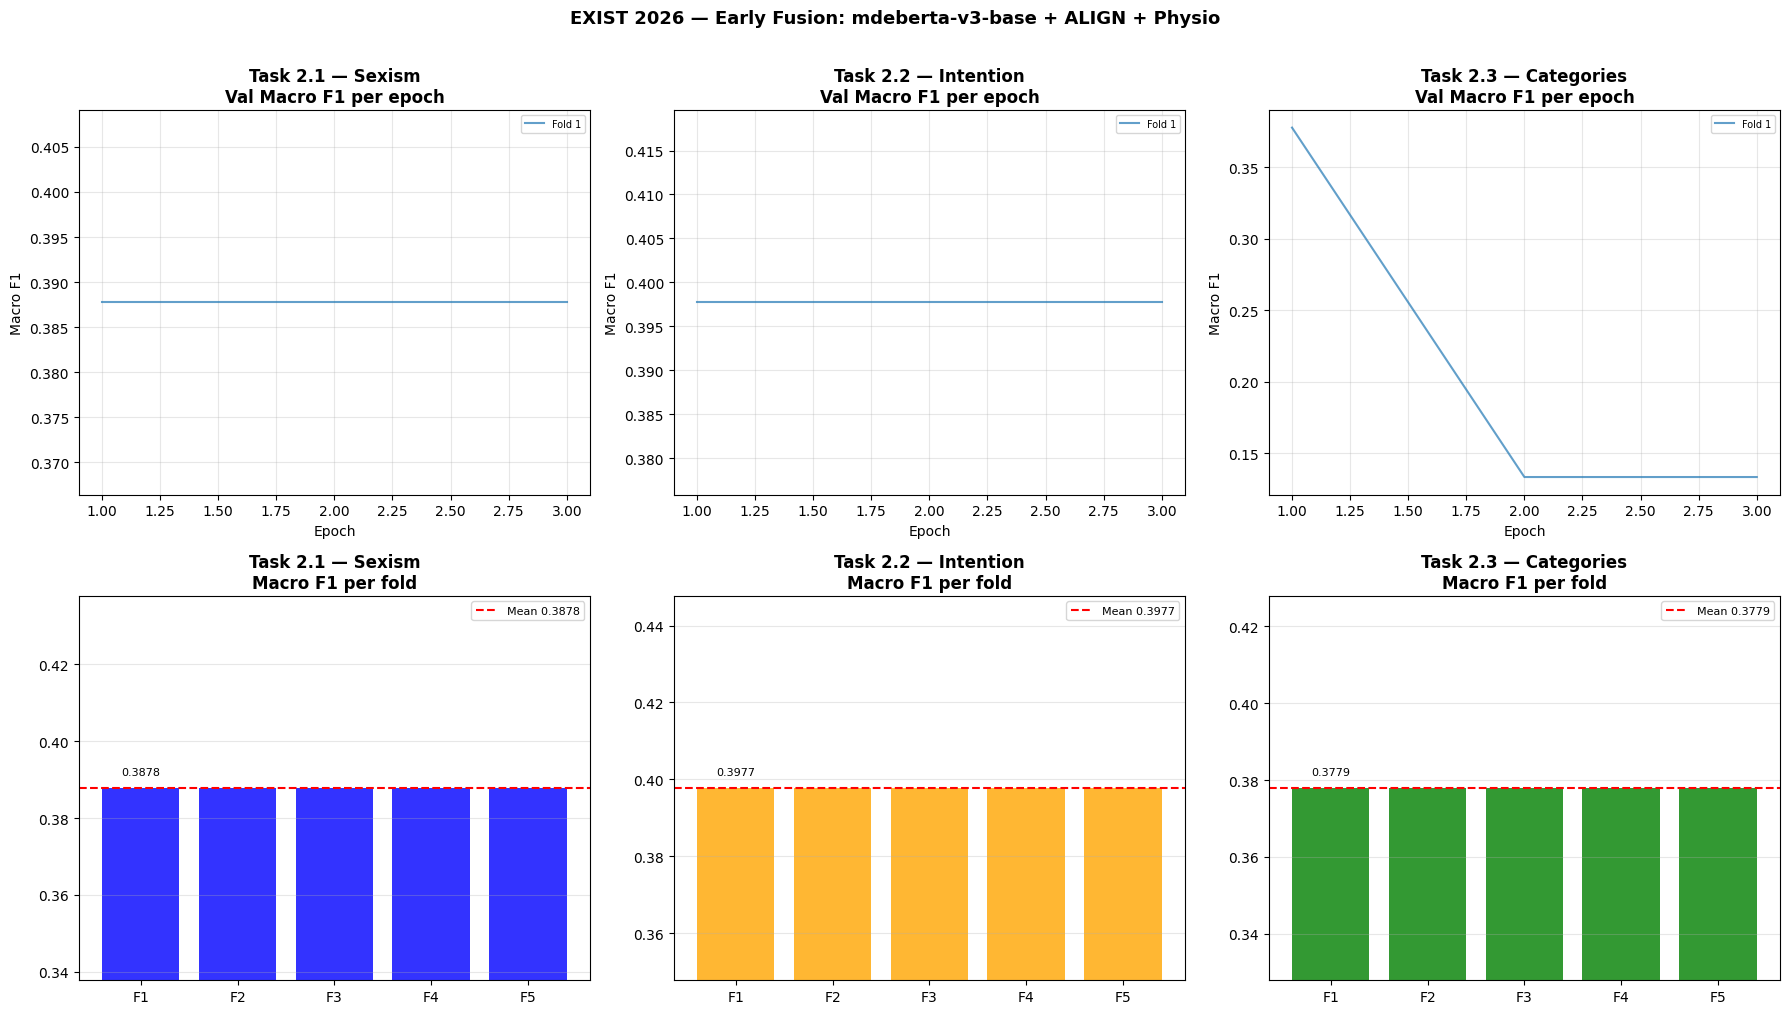

Plot saved in results/early_fusion_baseline/cv_results_mdeberta-v3-base.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

tasks  = ['21', '22', '23']
labels = ['Task 2.1 — Sexism', 'Task 2.2 — Intention', 'Task 2.3 — Categories']
colors = ['blue', 'orange', 'green']

for col, (task, label, color) in enumerate(zip(tasks, labels, colors)):

    # First plot: Training Curves (F1 per epoch all folds)
    ax = axes[0, col]
    for fold_n, hist_df in fold_histories.items():
        ax.plot(hist_df['epoch'], hist_df[f'f1_{task}'],
                alpha=0.7, linewidth=1.5, label=f'Fold {fold_n}')
    ax.set_title(f'{label}\nVal Macro F1 per epoch', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # Second plot: Bar chart of final F1 scores per fold with mean line
    ax = axes[1, col]
    vals = df_results[f'f1_{task}']
    bars = ax.bar([f'F{i}' for i in range(1, N_FOLDS+1)], vals, color=color, alpha=0.8)
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean {vals.mean():.4f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{label}\nMacro F1 per fold', fontweight='bold')
    ax.set_ylim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.05))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

model_tag = TEXT_MODEL_NAME.split('/')[-1]
plt.suptitle(f'EXIST 2026 — Early Fusion: {model_tag} + ALIGN + Physio',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, f'cv_results_{model_tag}.png')
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Plot saved in {plot_path}")